In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.holtwinters import Holt, ExponentialSmoothing
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [5]:
df = pd.read_csv("clean_normal_cells.csv")

df["Date"] = pd.to_datetime(df["Date"])

df = df.rename(
    columns={
        "(HU) Cell DL Average Throughput (Mbps)":
        "DL_Throughput"
    }
)

In [12]:
cell_name = df["Cell Name"].iloc[3]

cell_df = (
    df[df["Cell Name"] == cell_name]
    .sort_values("Date")
    .set_index("Date")
)

series = cell_df["DL_Throughput"]

In [13]:
FORECAST_HORIZON = 7

train = series[:-FORECAST_HORIZON]
test = series[-FORECAST_HORIZON:]

In [14]:
holt_model = Holt(
    train
).fit(optimized=True)

forecast_holt = holt_model.forecast(FORECAST_HORIZON)

c:\Users\M2h\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [15]:
hw_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='add',
    seasonal_periods=7
).fit()

forecast_hw = hw_model.forecast(FORECAST_HORIZON)

c:\Users\M2h\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


In [16]:
mae_holt = mean_absolute_error(
    test,
    forecast_holt
)

mae_hw = mean_absolute_error(
    test,
    forecast_hw
)

print("Holt MAE:", round(mae_holt,3))
print("Holt-Winters MAE:", round(mae_hw,3))

Holt MAE: 0.473
Holt-Winters MAE: 0.265


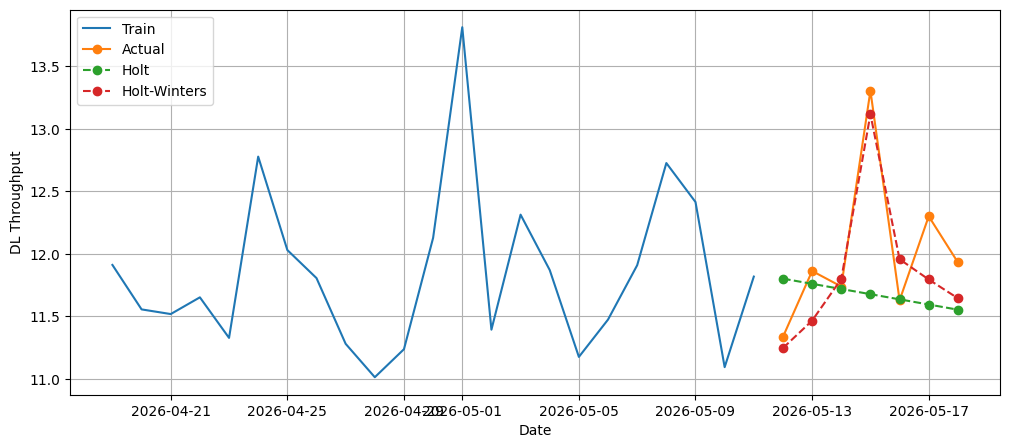

In [17]:
plt.figure(figsize=(12,5))

plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, marker='o', label="Actual")

plt.plot(
    test.index,
    forecast_holt,
    '--',
    marker='o',
    label="Holt"
)

plt.plot(
    test.index,
    forecast_hw,
    '--',
    marker='o',
    label="Holt-Winters"
)

plt.xlabel("Date")
plt.ylabel("DL Throughput")

plt.legend()
plt.grid()

plt.show()